In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SA01.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length

print(K)
print(T_d)

print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [5]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)

In [10]:
from training.dqn_agent import DQNAgent
from models.full_lattice import FullLatticeNetwork


agent = DQNAgent(
    env,
    QnetworkClass=lambda input_dim, output_dim: FullLatticeNetwork(
        input_dim     = input_dim,
        output_dim    = output_dim,
        c_range       = (0.0, 10.0),
        t_range       = (1.0, 50.0),
        r_range       = (0.0, 100.0),
        q_range       = (0.0, 10.0)
    ),
    monotonicity_penalty=False,
    reject_bias=0.75,
    gamma=0.99,
    epsilon_decay_steps=40000
)

In [11]:
reward_history, monotonicity_violations = agent.train(num_episodes=5000)

Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 40
  Systematic monotonicity (Episode 1): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 37
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 30
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 34
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 40
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 45
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 42
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 32
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 34
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 34
K

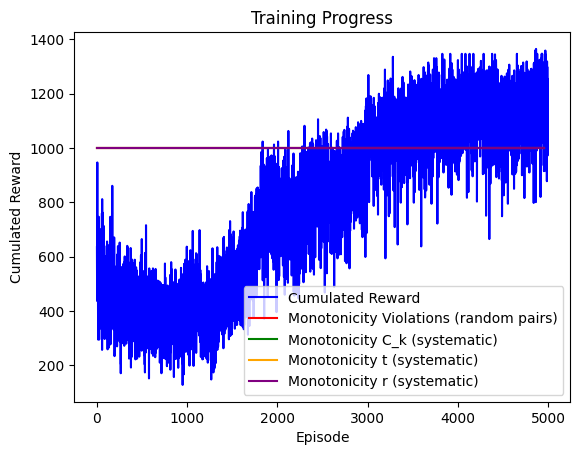

In [12]:
episodes = [x[0] for x in monotonicity_violations]
ratio    = [x[1] * 1000 for x in monotonicity_violations]
mono_c   = [x[2] * 1000 for x in monotonicity_violations]
mono_t   = [x[3] * 1000 for x in monotonicity_violations]
mono_r   = [x[4] * 1000 for x in monotonicity_violations]

plt.plot(reward_history, color="blue", label="Cumulated Reward")
plt.plot(episodes, ratio,  color="red",    label="Monotonicity Violations (random pairs)")
plt.plot(episodes, mono_c, color="green",  label="Monotonicity C_k (systematic)")
plt.plot(episodes, mono_t, color="orange", label="Monotonicity t (systematic)")
plt.plot(episodes, mono_r, color="purple", label="Monotonicity r (systematic)")
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress")
plt.legend()
plt.show()